In [24]:
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm
from utils.analysis import uq_get_obs, uq_get_sim
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

rcParams['font.size'] = 14
rcParams['axes.titlesize'] = 14

prefix_list = ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']
ens_member = [None, 'g03067', 'g01485', 'g01944']

chamber = 'TAMB'
plot = 'plot07'
#chamber = 'T9.00'
#plot = 'plot10'

hol_add = 17

In [25]:
nee_balance = {'NEE': [], 'GPP': [], 'AR': [], 'HR': []}

for varname in nee_balance.keys():
    df = pd.DataFrame(np.nan, index = range(1,366), columns = prefix_list)
    for prefix, ens_id in zip(prefix_list, ens_member):
        if 'UQ' in prefix:
            flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', ens_id, chamber,
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC.elm.h1.{year}-01-01-00000.nc')
                    for year in range(2015, 2022)]
        else:
            flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', 'spruce_treatments', 
                                f'{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run',
                                f'{plot}_US-SPR_ICB20TRCNPRDCTCBC.elm.h1.{year}-01-01-00000.nc')
                    for year in range(2015, 2022)]

        hr = xr.open_mfdataset(flist)
        temp = hr[varname][:,0].values*0.64 + hr[varname][:,1].values*0.36 # gC m-2 day-1
        df.loc[:, prefix] = np.mean(temp.reshape(-1,365), axis = 0) * 86400
        hr.close()
    nee_balance[varname] = df

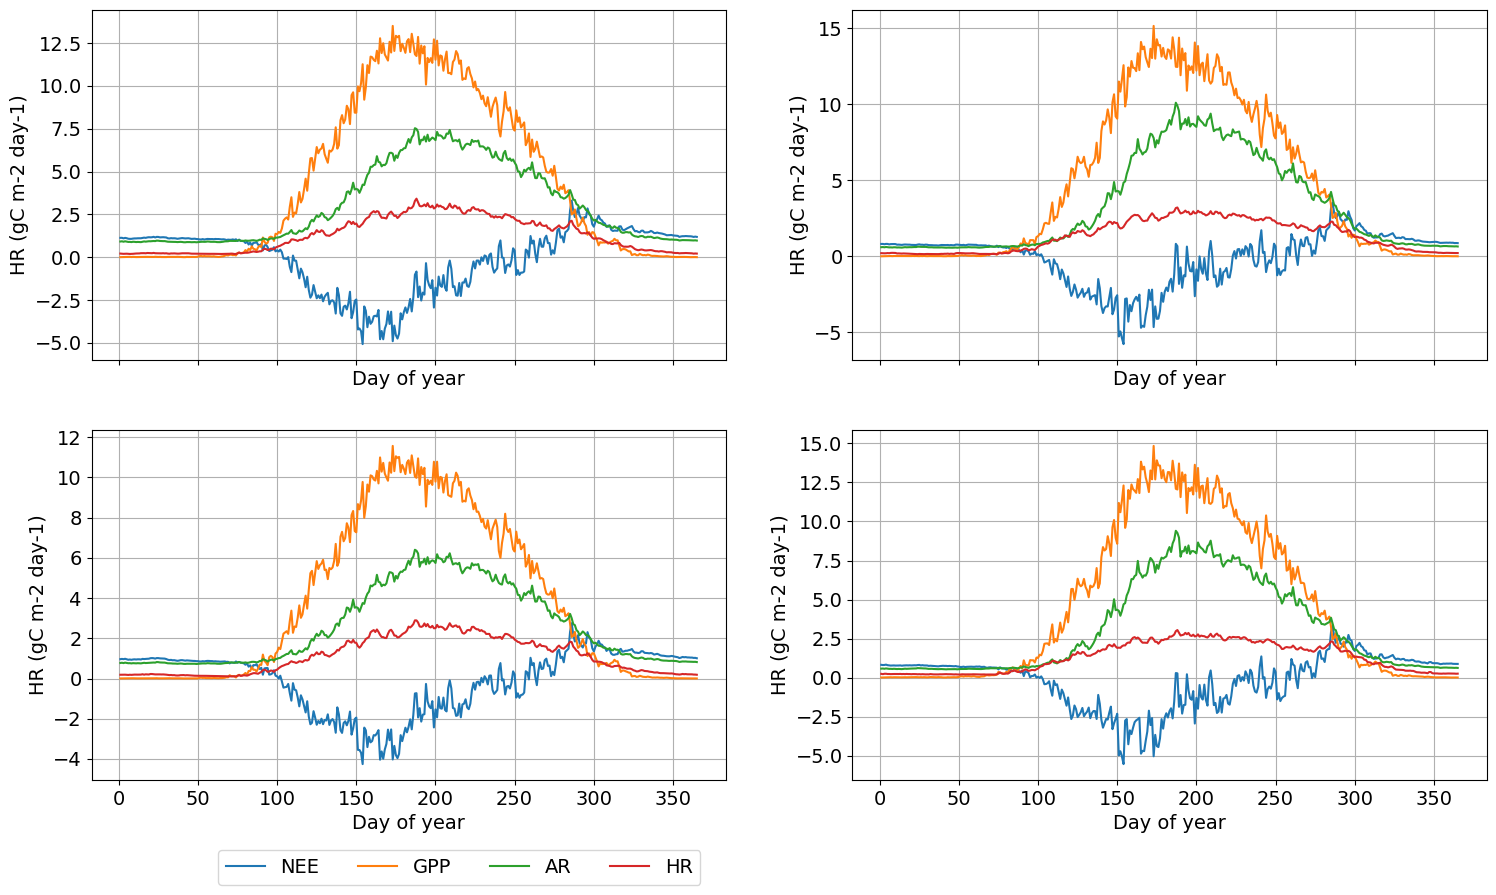

In [26]:
fig, axes = plt.subplots(2, 2, figsize = (18, 10), sharex = True)
for i, prefix in enumerate(prefix_list):
    ax = axes.flat[i]

    for var in nee_balance.keys():

        ax.plot(nee_balance[var].index, nee_balance[var].loc[:, prefix], '-', label = var)

        ax.set_ylabel(f'{var} (gC m-2 day-1)')
        ax.set_xlabel('Day of year')
        ax.grid(True)
ax.legend(ncol = 4, loc = (-1, -0.3))

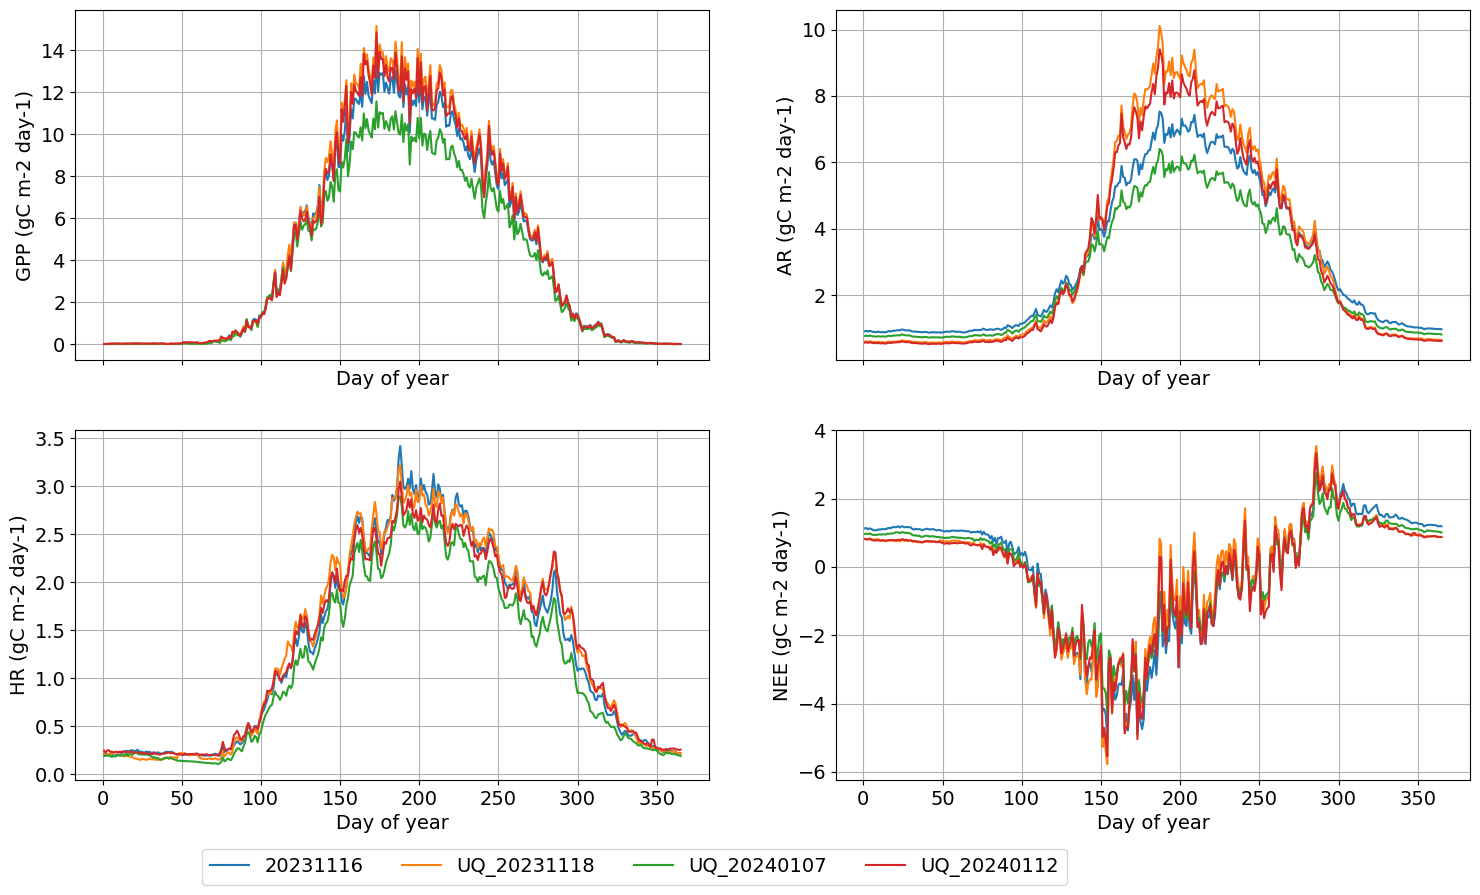

In [27]:
# same as above but plotted in a different way
fig, axes = plt.subplots(2, 2, figsize = (18, 10), sharex = True)
for i, var in enumerate(['GPP','AR','HR','NEE']):
    ax = axes.flat[i]
    for prefix in prefix_list:
        ax.plot(nee_balance[var].index, nee_balance[var].loc[:, prefix], 
                '-', zorder = 3, label = prefix)
        ax.set_ylabel(f'{var} (gC m-2 day-1)')
        ax.set_xlabel('Day of year')
        ax.grid(True)
ax.legend(ncol = 4, loc = (-1, -0.3))